# Dataset creation (raw CSVs → MongoDB)

End-to-end pipeline that:
1. Discovers raw `acc`/`gyr` CSVs under `data/`.
2. Pairs them by session key, merges on `Epoch` and applies a zero-phase Butterworth lowpass
3. Saves a static 6-axis time-series plot and a 3D acc/gyr scatter per session under `outputs/figures/`.
4. Inserts one merged document per session into the MongoDB collection from `config.yml`.

All heavy lifting lives in `utils.py` and `utils_visual.py` — this notebook is just orchestration.

> **Prerequisite:** MongoDB is running locally (`mongod` service up). On macOS: `brew services start mongodb-community`. On Windows: `net start MongoDB`. on Linux terminal to start MongoDB shel use the `mongosh`


## Setup

In [1]:
import os
from pathlib import Path
from collections import Counter

import yaml
from IPython.display import Image
from pathlib import Path

import utils
from utils import (
    discover_csvs, pair_acc_gyr, load_session, build_document,
    mongo_connect, insert_documents,
)
import utils_visual

## Load configuration

In [2]:
BASE_DIR = Path(os.getcwd()).resolve()

config_path = BASE_DIR / "config.yml"
with open(config_path, encoding='utf-8') as f:
    config = yaml.safe_load(f)
DATA_DIR = (BASE_DIR / config["data_path"]).resolve()
FIGURES_DIR = (BASE_DIR / config.get("out_figures", "outputs/figures")).resolve()

print("data:    ", DATA_DIR)
print("figures: ", FIGURES_DIR)

data:     /home/stamyk/Documents/GitHub/social-media-gesture-recognition/data_sync
figures:  /home/stamyk/Documents/GitHub/social-media-gesture-recognition/outputs/figures


## 1. Discover & pair raw CSVs

Each session has **two** raw CSVs (`acc` + `gyr` separately). We pair them by their shared key `(gesture_id, finger, typing_style, hand, primary, user)` — the only field that differs is `sensor`.

In [3]:
csvs = discover_csvs(DATA_DIR)
print(f"Found {len(csvs)} CSV files")

#μπορει να γινει και αλλιως
pairs = list(pair_acc_gyr(csvs))
print(f"Paired {len(pairs)} sessions (expecting 27 = 9 gesture×variant × 3 users)")

# Quick sanity: balance per (gesture, user)
Counter((m["gesture_id"], m["user"]) for m, _, _ in pairs)

#return a dictionary --> look if it works
all_users = utils.ProcessingData(pairs)


Found 54 CSV files
Paired 27 sessions (expecting 27 = 9 gesture×variant × 3 users)
Epoch      int64
acc_x    float64
acc_y    float64
acc_z    float64
gyr_x    float64
gyr_y    float64
gyr_z    float64
dtype: object


## 2. Load & Organize Data from Weareble

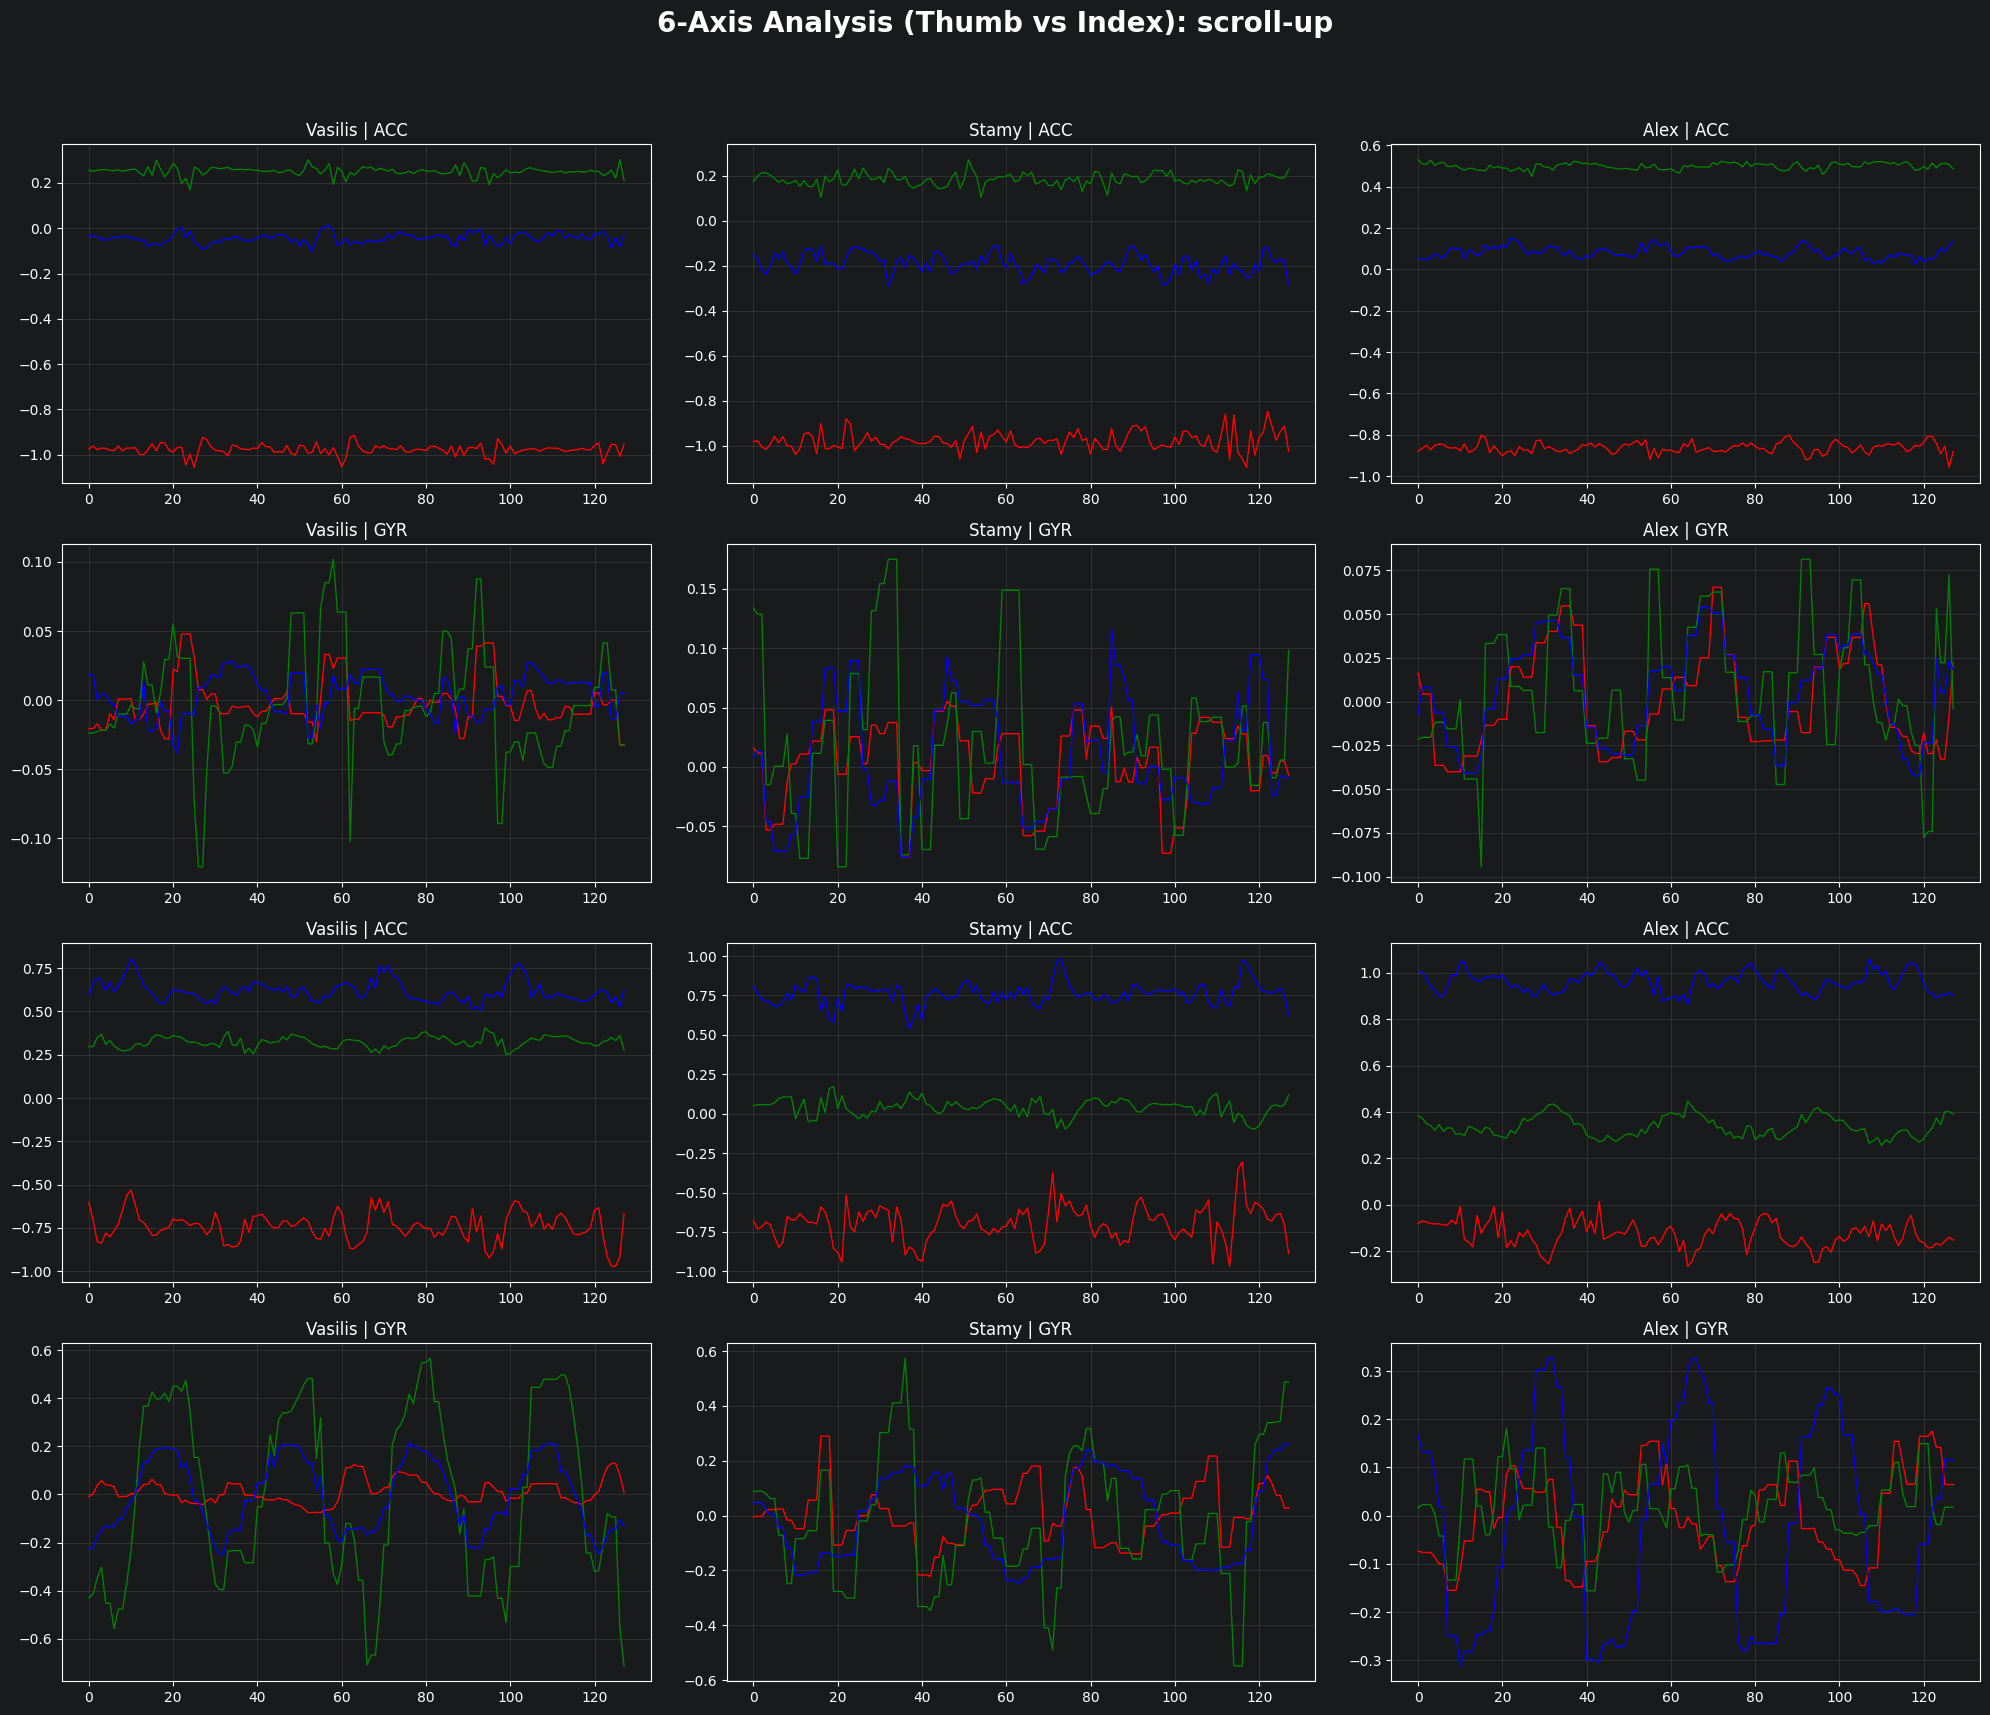

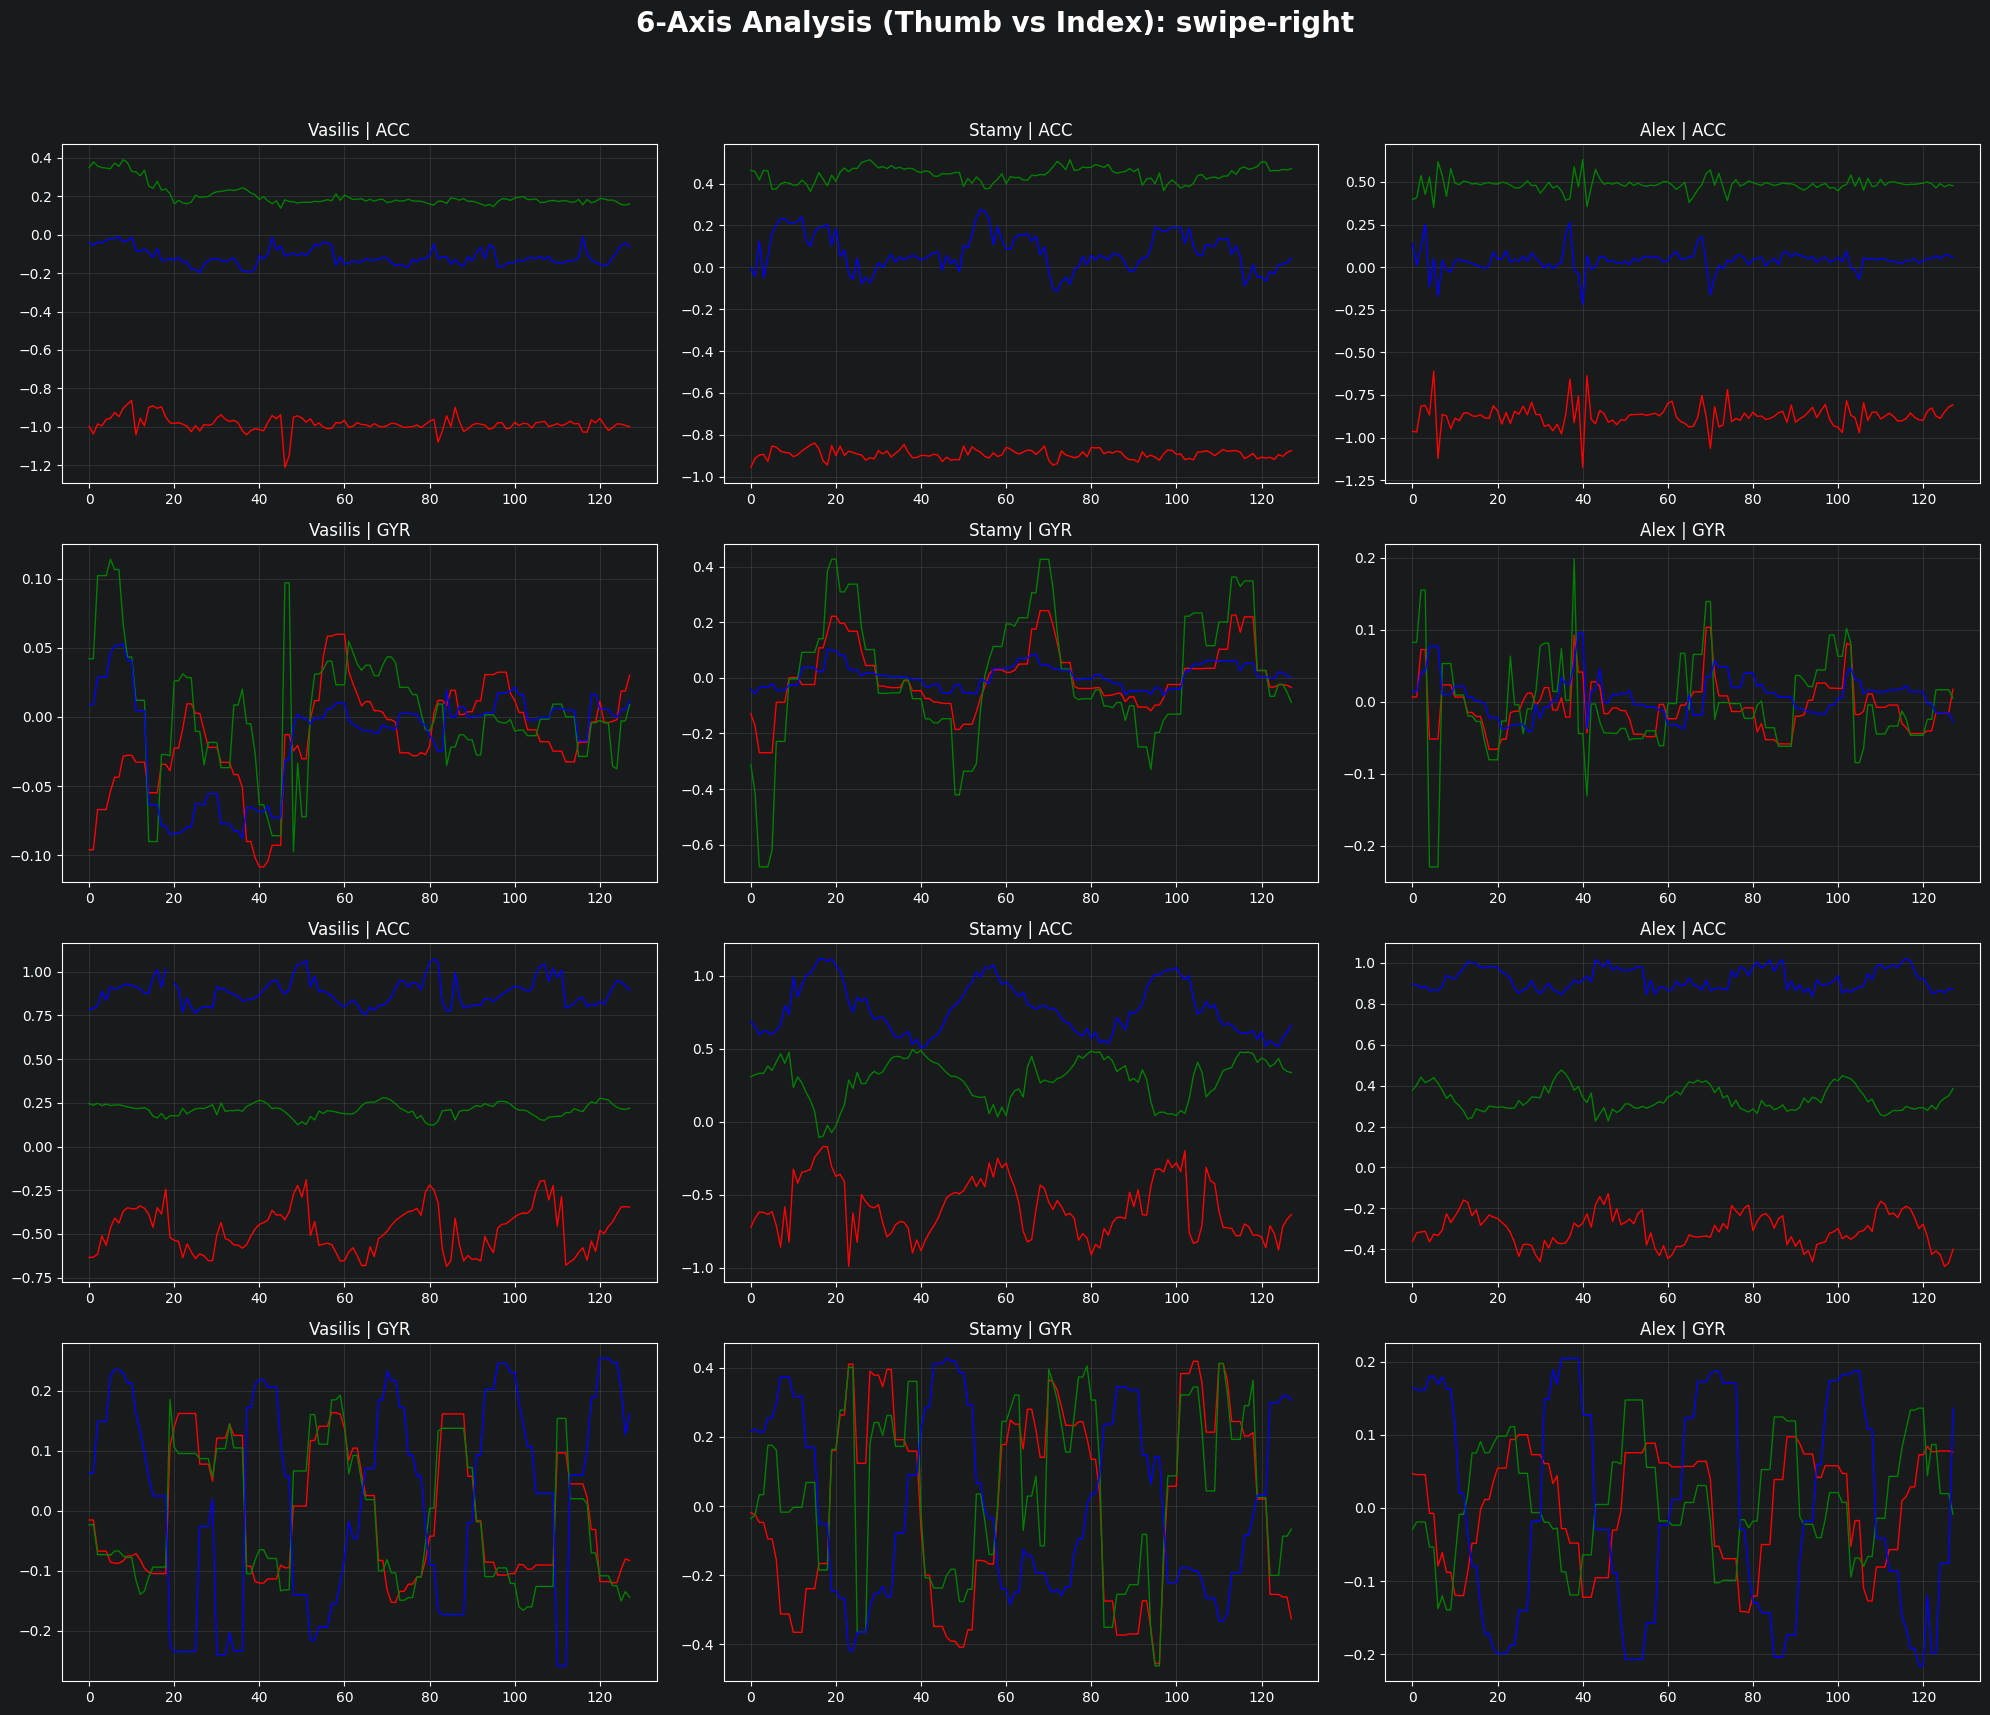

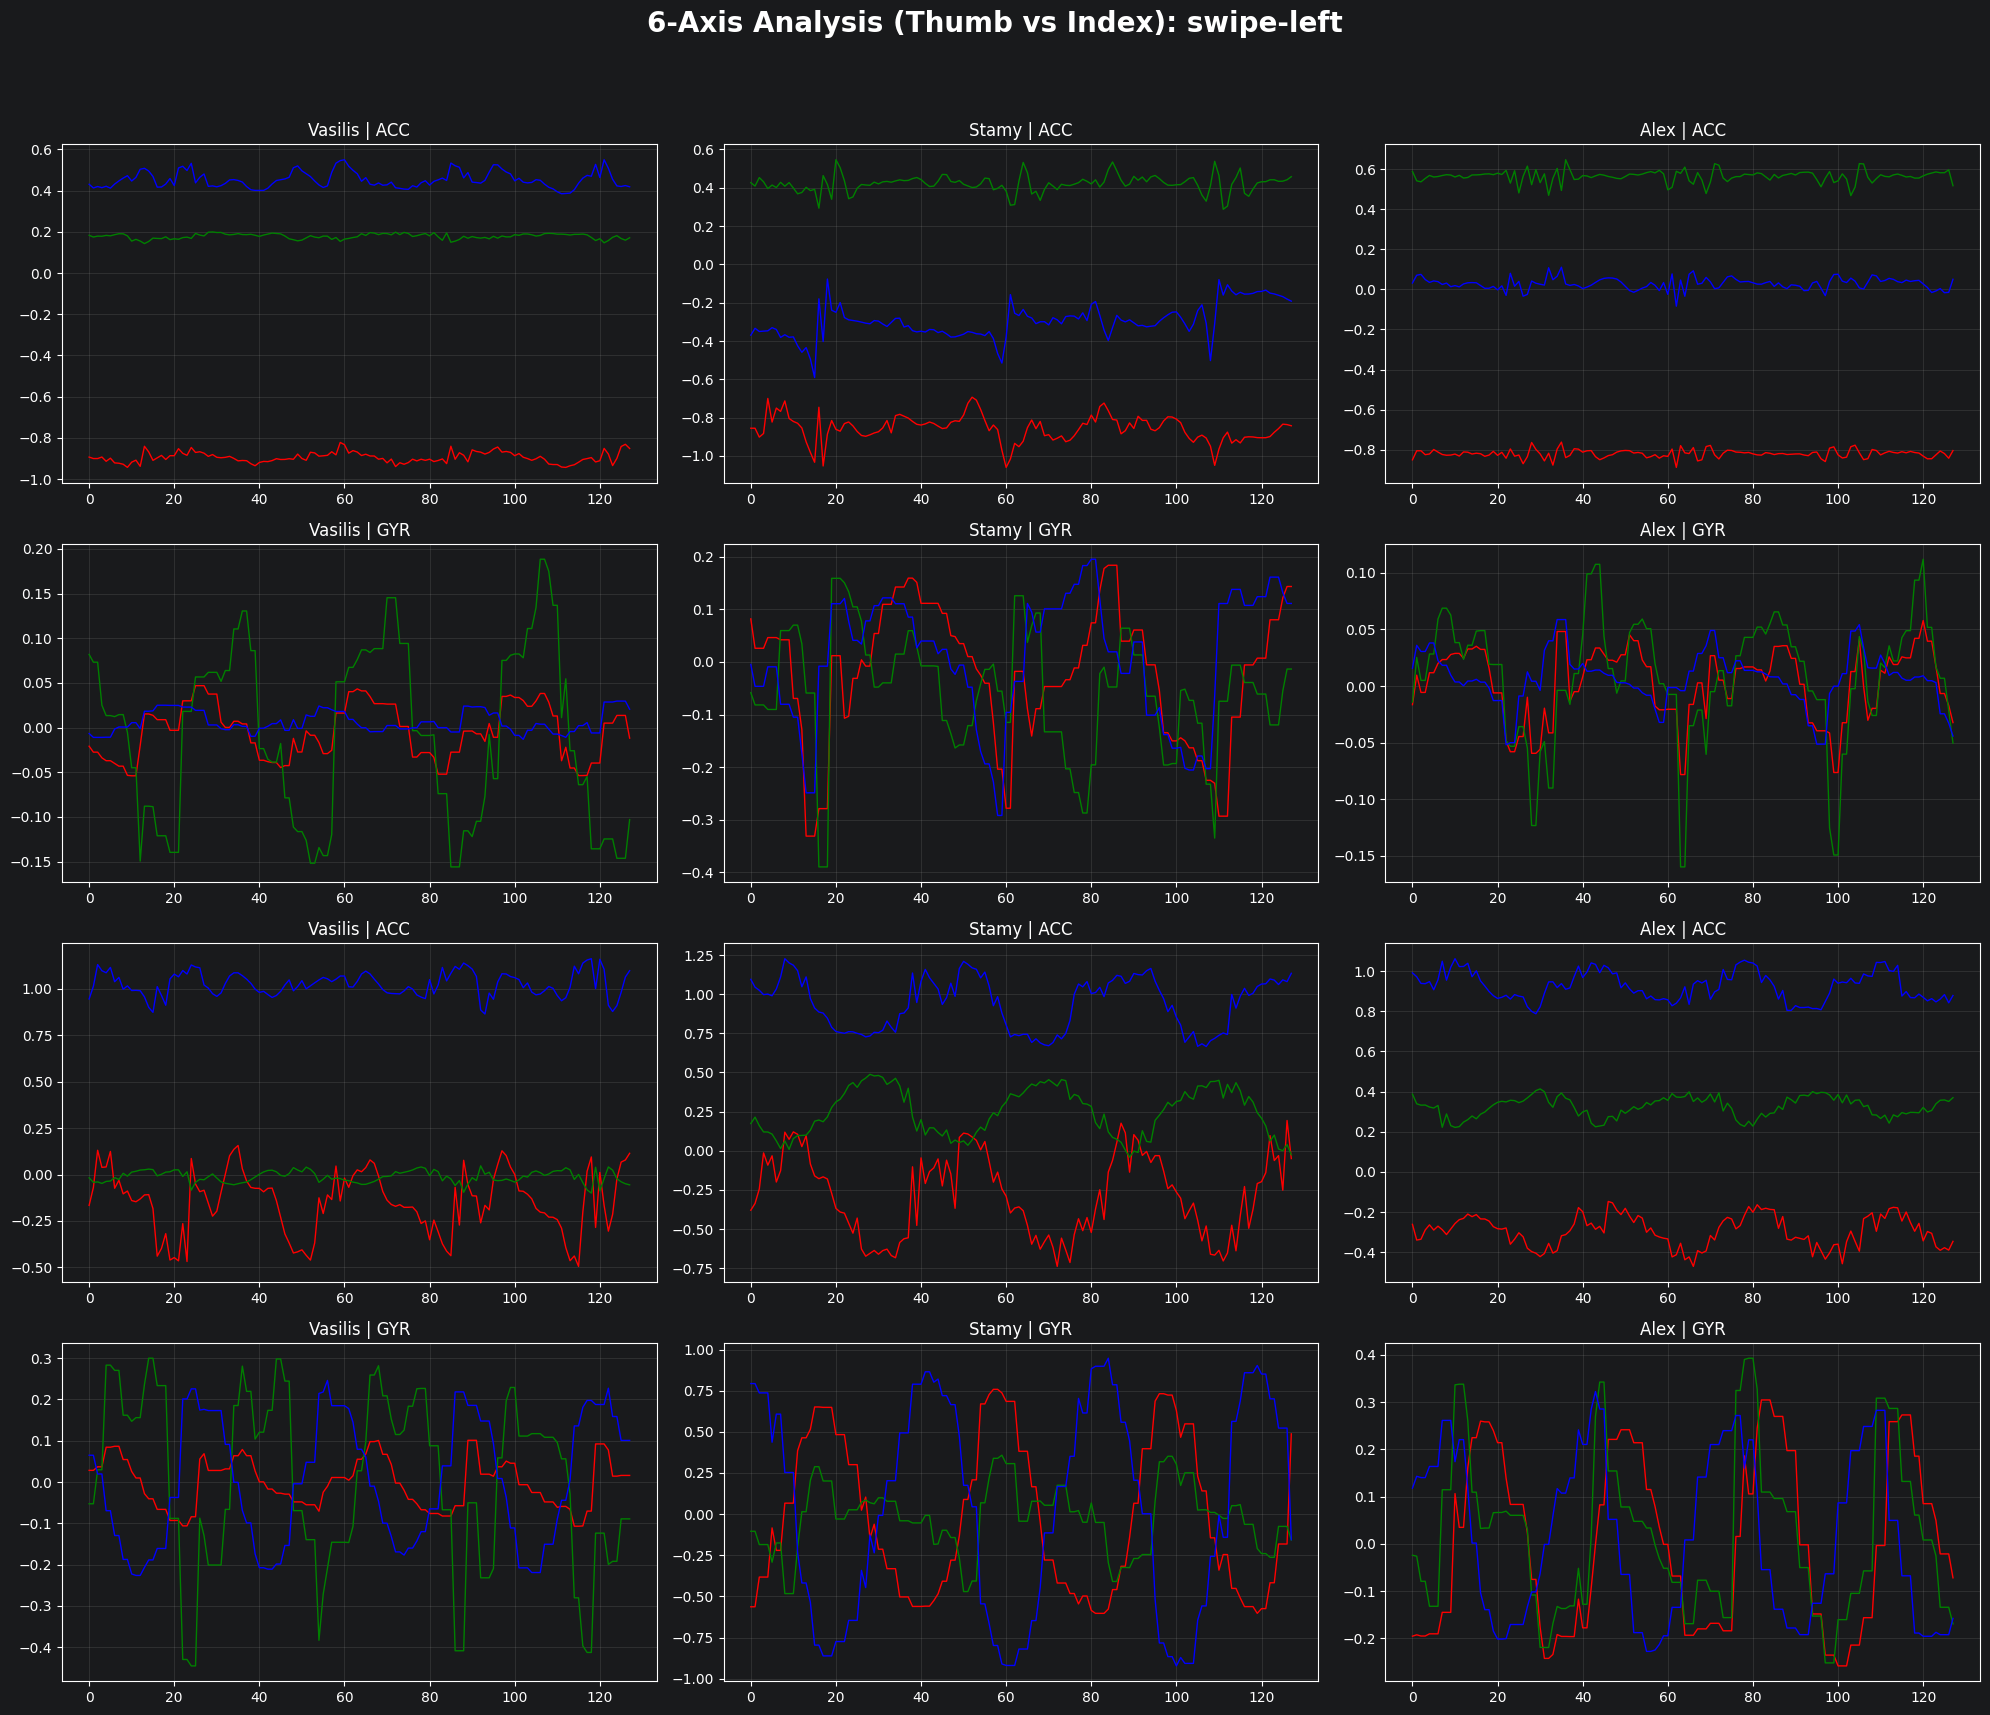

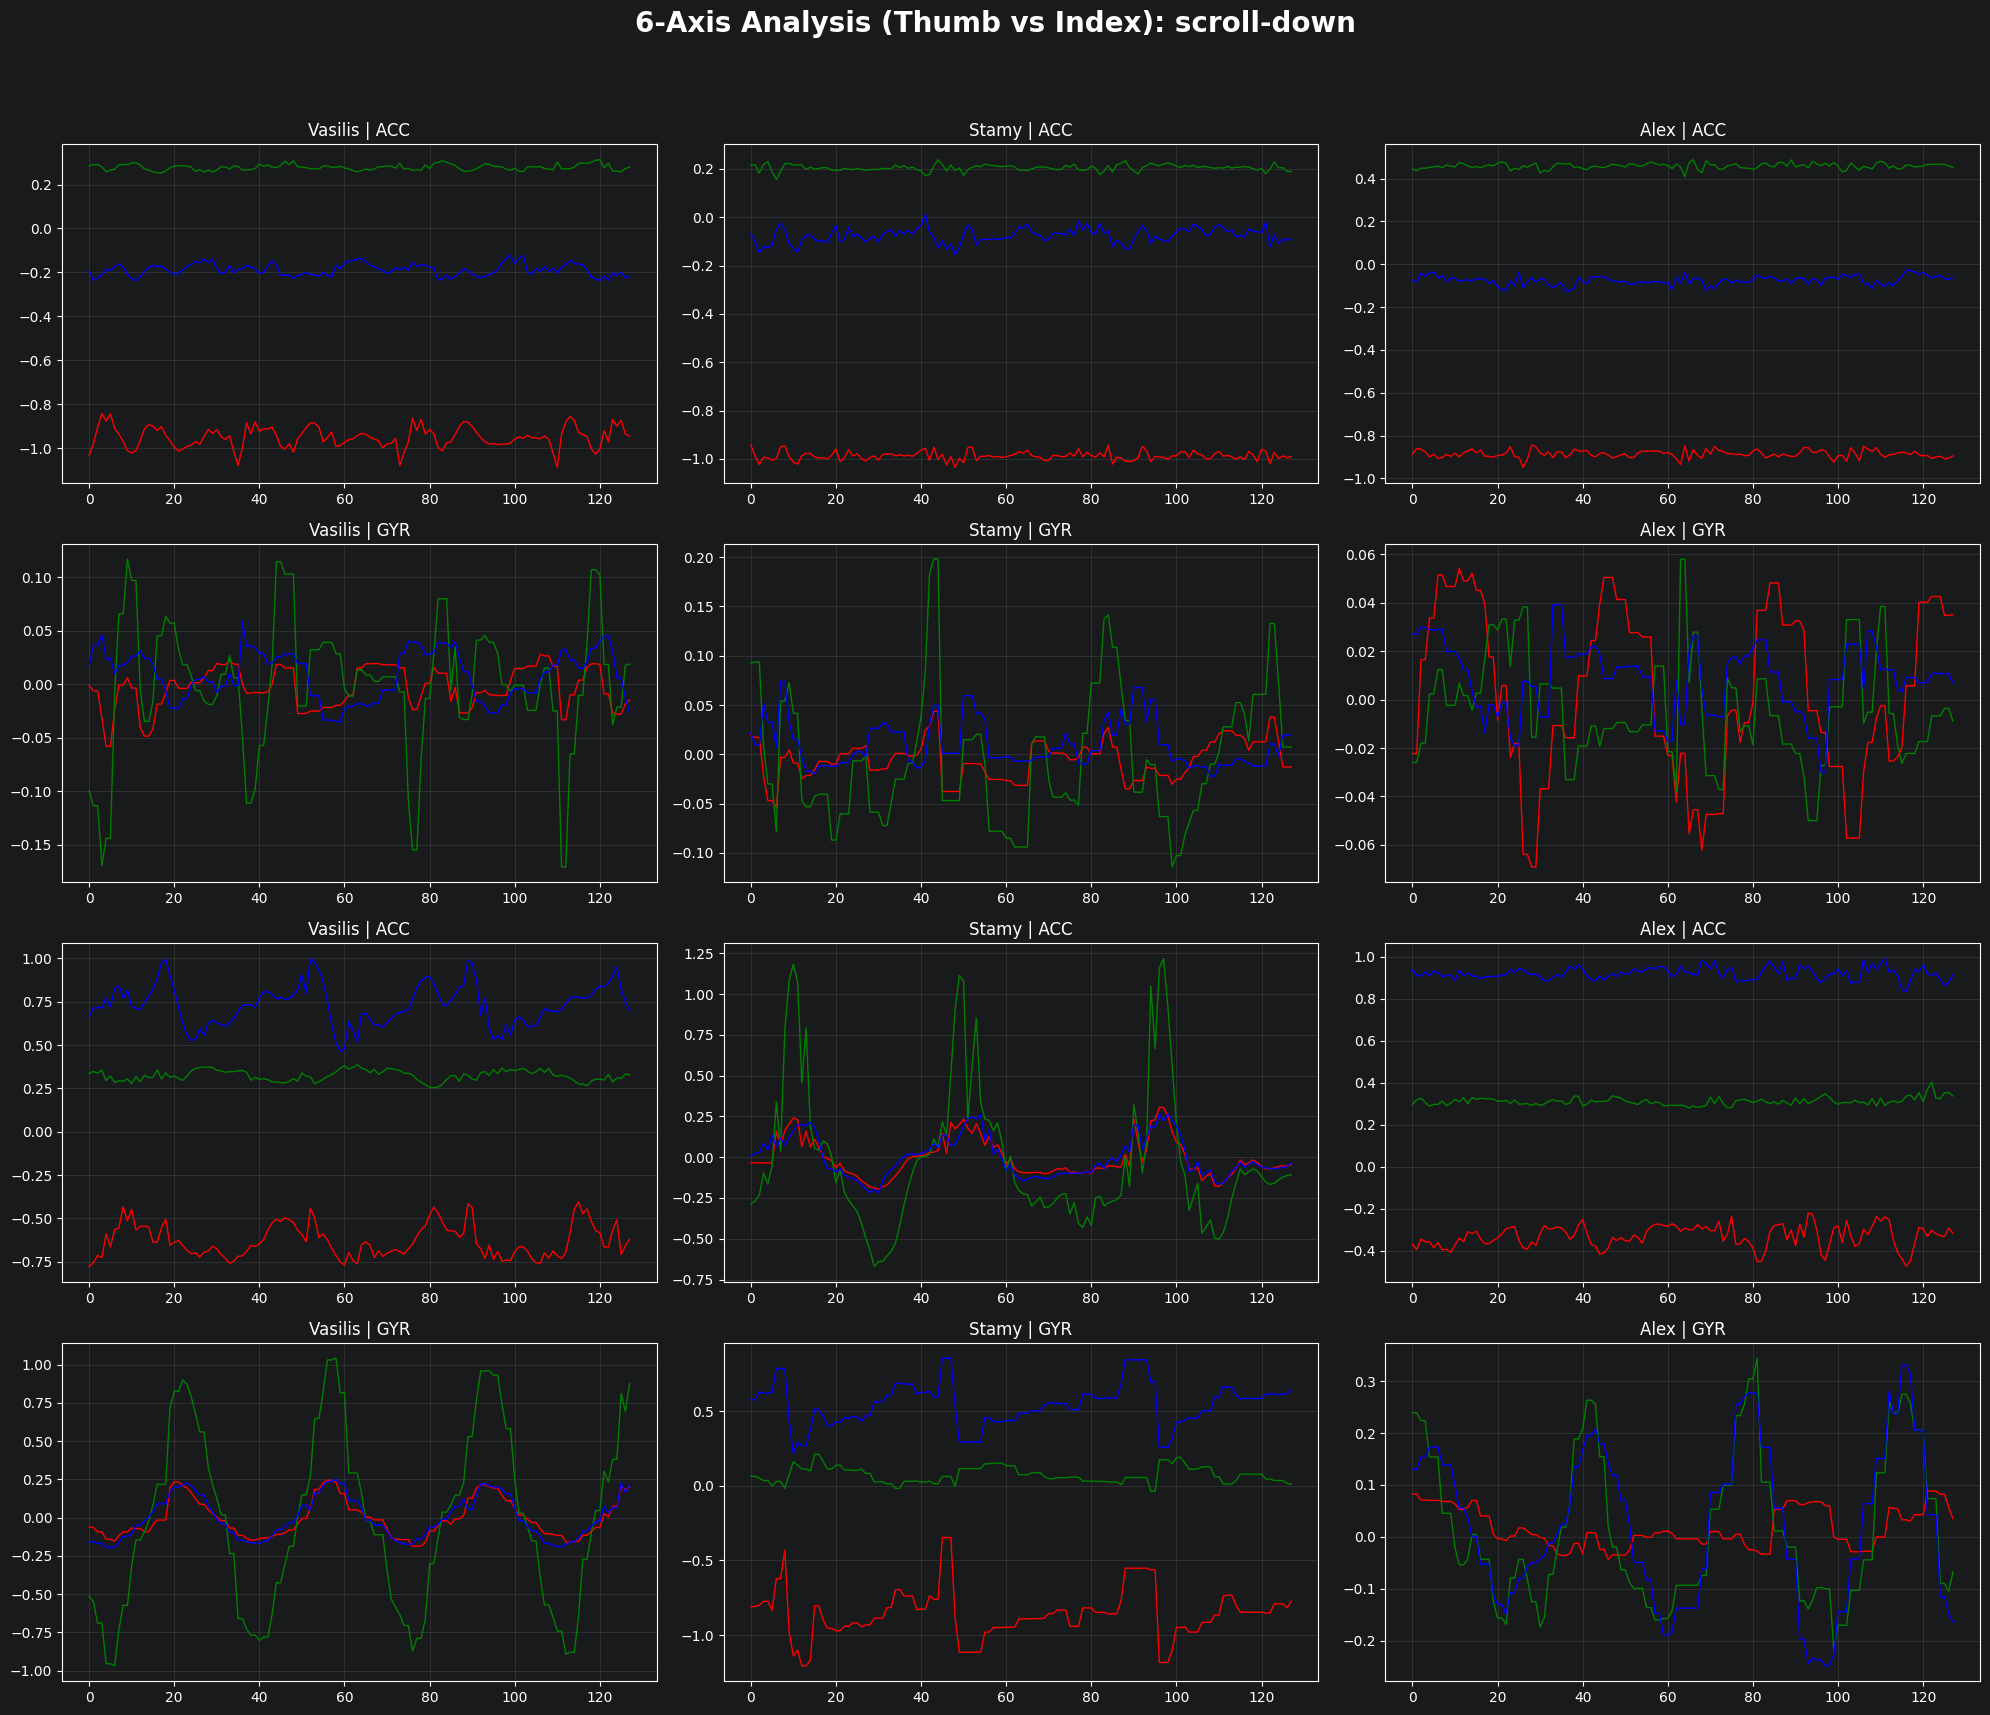

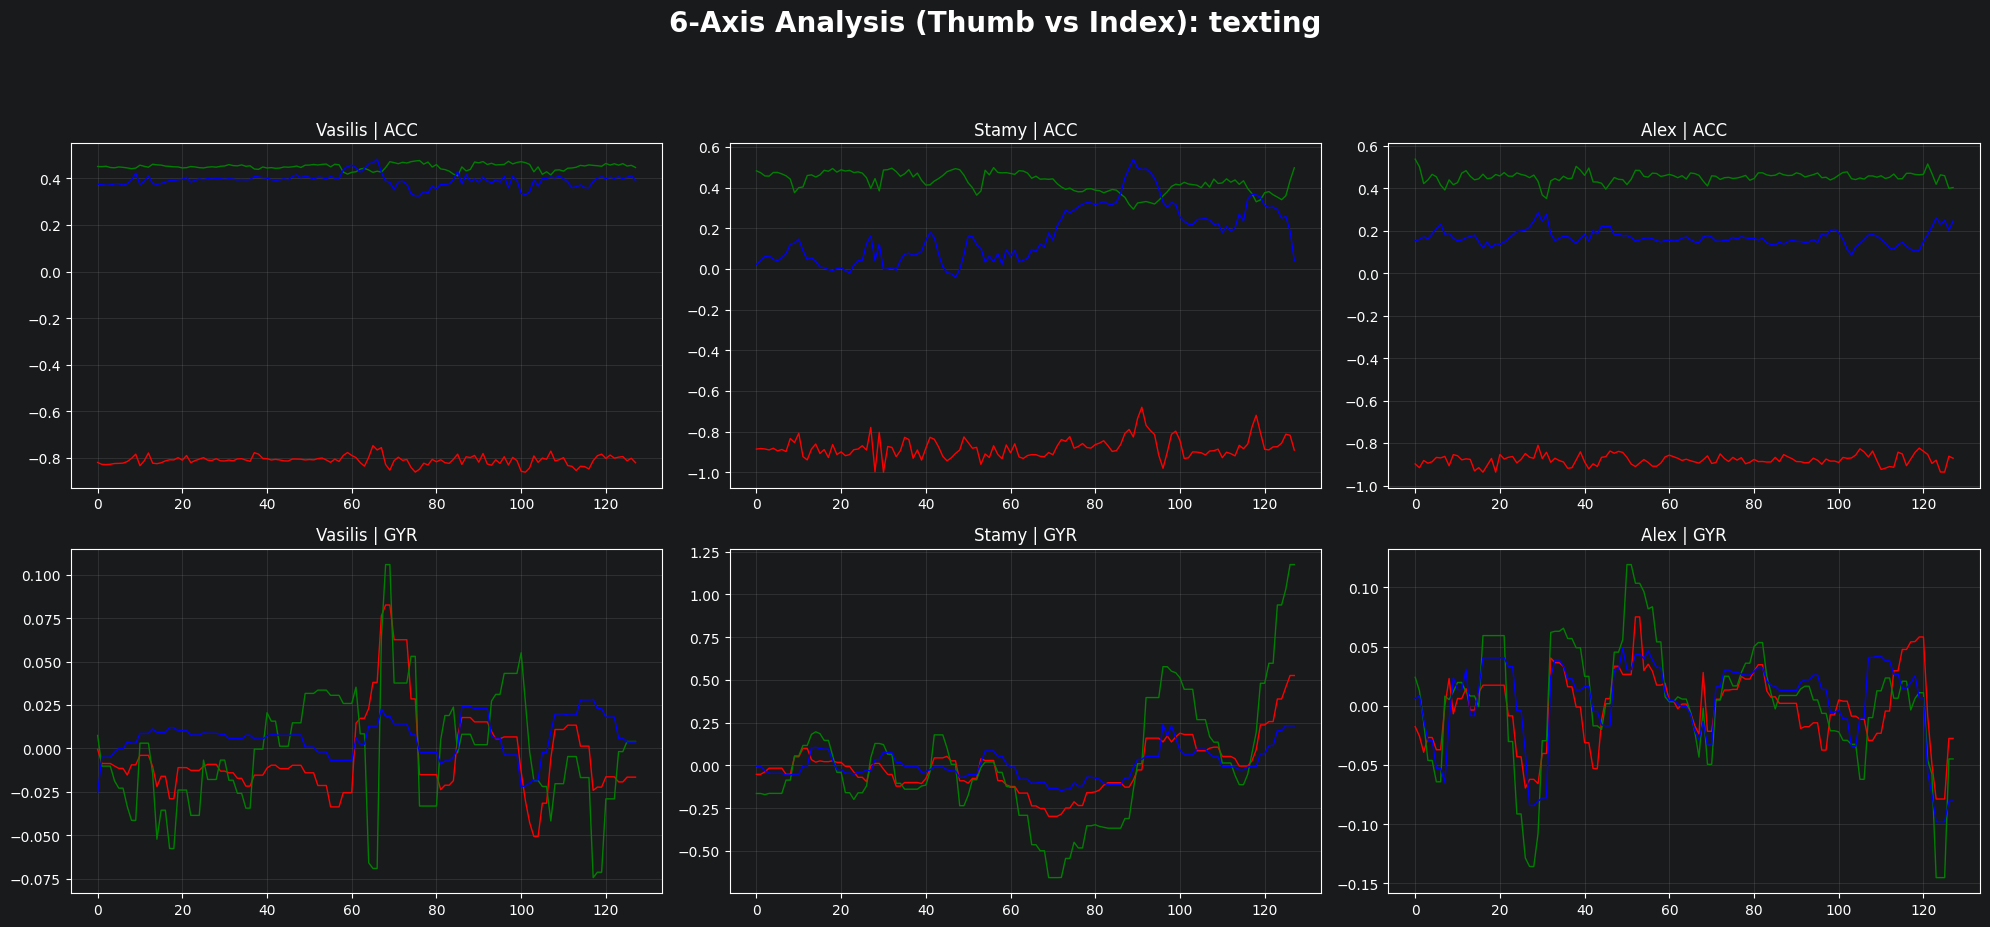

In [4]:
utils_visual.Plot_6axis(all_users)

## 4. Insert into MongoDB

`mongo_connect(reset=True)` clears existing documents in the collection (idempotent re-run) and creates a unique index on `session_id`.

In [8]:
coll = mongo_connect(uri=config["client"], db=config["db"], collection=config["col"], reset=True)
print(f"Connected to {coll.full_name}")

docs = (build_document(df, meta) for df, meta in sessions)
n_ins = insert_documents(coll, docs)
print(f"Inserted {n_ins} documents")

InvalidName: database names cannot contain the character ' '

## 5. Verification

In [ ]:
assert coll.count_documents({}) == len(sessions), "Document count mismatch"

# Count per gesture
from collections import Counter
gestures = Counter(d["gesture_id"] for d in coll.find({}, {"gesture_id": 1}))
print("Per gesture:", dict(gestures))

# Inspect one document (without the heavy `data` field)
sample = coll.find_one({}, {"data": 0})
sample